# Unsupervised baseline: PCA → k-means (+ hyperparameter experiments)

**Data:** `food_nutrient_conc.csv` in the parent folder (`StatLearning_FinalProject/`), one row per food.

**Features:** By default `load_feature_matrix` uses **micronutrient-only** columns (`nutrient_definitions.py`, same rules as `R/nutrient_definitions.R`).

**CLI:** from `unsupervised_learning/` run `python unsupervised_pca_kmeans.py` (add `--all-numeric-nutrients` for every numeric column).

**Outputs:** figures in **`plots/unsupervised/`**; assignments + run summary in **`results/`**. Notebook grid exports: **`results/unsupervised_grid_k_m_metrics.csv`** and **`results/unsupervised_grid_k_no_pca_metrics.csv`**.

**Notebook:** imports resolve whether your Jupyter working directory is `StatLearning_FinalProject` or `unsupervised_learning`.

**Later sections:** grid search over `K` (clusters) and `m` (PCs used for k-means), a no-PCA ablation, stability across seeds, and PC loadings for narrative.

In [1]:
%matplotlib inline

import sys
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import display
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from sklearn.impute import SimpleImputer
from sklearn.metrics import adjusted_rand_score, calinski_harabasz_score, silhouette_score
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler

# Resolve sibling folder whether Jupyter cwd is repo root or unsupervised_learning/
_cwd = Path.cwd().resolve()
for _p in (_cwd, _cwd / "unsupervised_learning"):
    if (_p / "unsupervised_pca_kmeans.py").is_file():
        if str(_p) not in sys.path:
            sys.path.insert(0, str(_p))
        break
else:
    raise ImportError(
        "Place cwd at StatLearning_FinalProject or unsupervised_learning "
        "so unsupervised_pca_kmeans.py can be imported."
    )

from unsupervised_pca_kmeans import (
    DEFAULT_K_CLUSTERS,
    DEFAULT_N_COMPONENTS_KMEANS,
    PLOTS_DIR_UNSUPERVISED,
    PROJECT_ROOT,
    RESULTS_DIR,
    SCREE_PLOT_COMPONENTS,
    fit_pca_kmeans,
    load_feature_matrix,
)

In [2]:
DATA_PATH = PROJECT_ROOT / "food_nutrient_conc.csv"

PLOTS_DIR_UNSUPERVISED.mkdir(parents=True, exist_ok=True)
RESULTS_DIR.mkdir(parents=True, exist_ok=True)

K = DEFAULT_K_CLUSTERS
PC_FOR_KMEANS = DEFAULT_N_COMPONENTS_KMEANS
RANDOM_SEED = 42

assert DATA_PATH.is_file(), f"Missing data file: {DATA_PATH}"

In [3]:
X_raw, food_names = load_feature_matrix(DATA_PATH)
print(f"Foods: {len(X_raw):,} | Nutrient features: {X_raw.shape[1]}")
X_raw.head()

Foods: 5,431 | Nutrient features: 34


,"Calcium, Ca",Retinol,Lycopene,"Carotene, beta",Thiamin,"Vitamin B-12, added","Phosphorus, P",Folic acid,Vitamin E (alpha-tocopherol),Vitamin B-6,...,Vitamin D (D2 + D3),"Potassium, K","Iron, Fe","Selenium, Se","Vitamin A, RAE","Vitamin E, added","Folate, total","Sodium, Na","Vitamin C, total ascorbic acid",Theobromine
0,125,57,0,4,0.057,0.0,103,0,0.03,0.061,...,1.1,156,0.0,1.9,58,0.0,1,39,0.1,0
1,123,31,0,7,0.056,0.0,101,0,0.05,0.061,...,1.1,150,0.0,1.9,32,0.0,0,38,0.0,0
2,126,83,0,3,0.059,0.0,103,0,0.03,0.061,...,1.1,159,0.0,1.8,83,0.0,2,39,0.2,0
3,126,58,0,1,0.057,0.0,103,0,0.02,0.060,...,1.1,159,0.0,2.1,58,0.0,2,39,0.0,0
4,132,64,0,2,0.056,0.0,107,0,0.00,0.058,...,1.1,167,0.0,2.0,64,0.0,2,41,0.0,0


In [4]:
result = fit_pca_kmeans(
    X_raw,
    food_names,
    k=K,
    pc_kmeans=PC_FOR_KMEANS,
    seed=RANDOM_SEED,
)

evr = result.pca.explained_variance_ratio_
cum = np.cumsum(evr)
print(f"K-means: K={K}, PCs used for clustering={result.n_pc_kmeans}")
print(f"Inertia: {result.kmeans.inertia_:,.2f} | Silhouette: {result.silhouette:.4f}")
print(
    f"Variance: PC1={evr[0]*100:.2f}% | PC2={evr[1]*100:.2f}% | "
    f"Cumulative (first {result.n_pc_kmeans} PCs)={cum[result.n_pc_kmeans - 1]*100:.2f}%"
)

K-means: K=8, PCs used for clustering=15
Inertia: 86,691.24 | Silhouette: 0.2461
Variance: PC1=21.25% | PC2=9.50% | Cumulative (first 15 PCs)=82.80%


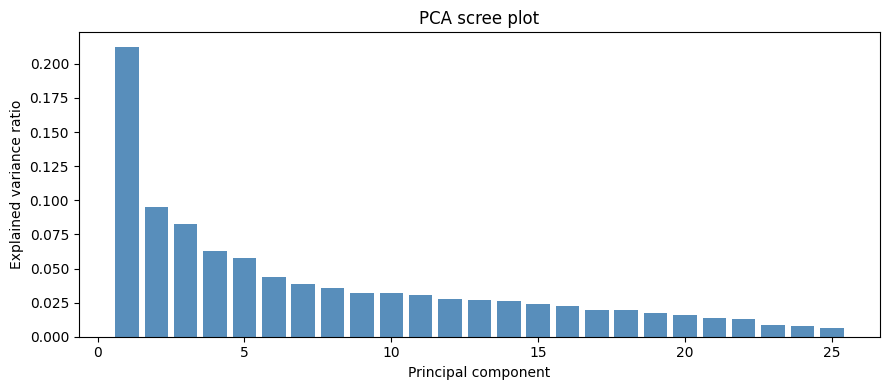

In [5]:
n_scree = min(SCREE_PLOT_COMPONENTS, len(evr))
fig, ax = plt.subplots(figsize=(9, 4))
ax.bar(np.arange(1, n_scree + 1), evr[:n_scree], color="steelblue", alpha=0.9)
ax.set_xlabel("Principal component")
ax.set_ylabel("Explained variance ratio")
ax.set_title("PCA scree plot")
fig.tight_layout()

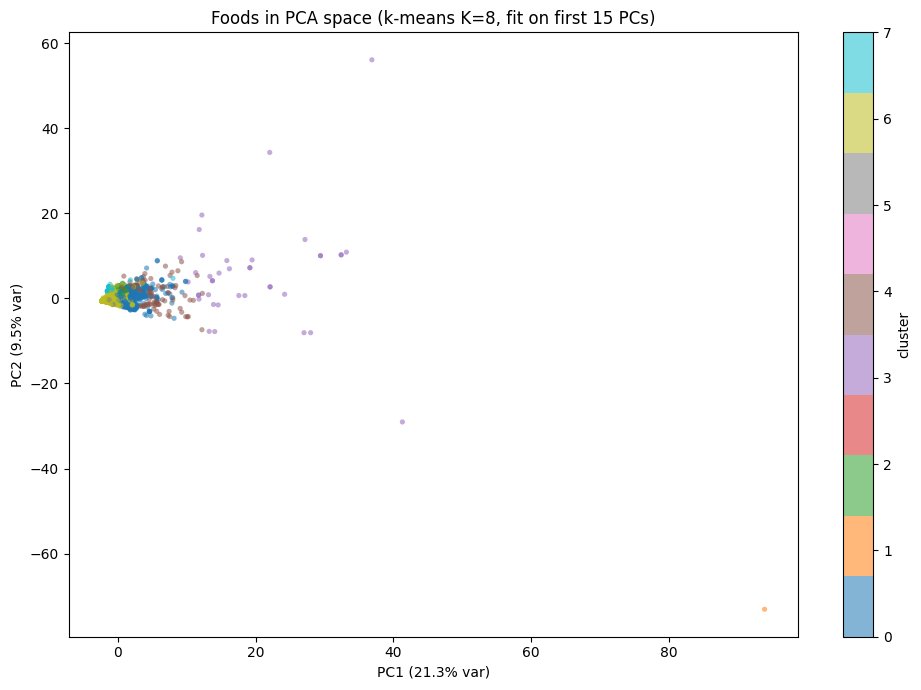

In [6]:
Z = result.Z
fig, ax = plt.subplots(figsize=(10, 7))
sc = ax.scatter(
    Z[:, 0],
    Z[:, 1],
    c=result.cluster_labels,
    cmap="tab10",
    alpha=0.55,
    s=14,
    linewidths=0,
)
ax.set_xlabel(f"PC1 ({evr[0]*100:.1f}% var)")
ax.set_ylabel(f"PC2 ({evr[1]*100:.1f}% var)")
ax.set_title(
    f"Foods in PCA space (k-means K={K}, fit on first {result.n_pc_kmeans} PCs)"
)
plt.colorbar(sc, ax=ax, label="cluster")
fig.tight_layout()

In [7]:
assignments = pd.DataFrame(
    {
        "Food_Name": result.food_names.values,
        "PC1": Z[:, 0],
        "PC2": Z[:, 1],
        "cluster": result.cluster_labels,
    }
)
assignments.groupby("cluster")["Food_Name"].count().rename("n_foods")

cluster
0    1859
1       1
2      71
3      39
4     327
5     221
6    2863
7      50
Name: n_foods, dtype: int64

In [8]:
assignments.sort_values("PC1").tail(8)

,Food_Name,PC1,PC2,cluster
5353,Nutritional powder mix (Slim Fast),29.401091,10.040740,3
5354,"Nutritional powder mix, sugar free (Slim Fast)",29.401091,10.040740,3
5349,"Nutritional powder mix, high protein (Herbalife)",32.403699,10.244992,3
5357,"Nutritional powder mix, high protein, NFS",32.403699,10.244992,3
5355,"Nutritional powder mix, high protein (Slim Fast)",33.163158,10.878487,3
769,"Liver, beef",36.863083,56.099939,3
4621,Yeast,41.292734,-29.037686,3
4622,Yeast extract spread,93.864165,-73.076179,1


## Hyperparameter experiments

**Motivation:** The baseline fixes \(K=8\) clusters and uses \(m=15\) principal components for k-means. We treat both as *tunable*: domain knowledge suggests a rough scale for \(K\); the number of PCs controls how much of the PCA subspace shapes Euclidean distance before clustering.

**Procedure:** Median-impute and scale (same as baseline). Fit **one** full PCA to get scores `Z`. For each pair \((K, m)\), run k-means on `Z[:, :m]` and record **silhouette** (primary), **inertia**, and **Calinski–Harabasz** in that same \(m\)-dimensional space.

**Ablation:** k-means on the **same** scaled micronutrient matrix without PCA (\(p\) equals the number of micronutrient columns, e.g. 34) for each \(K\), with silhouette in that \(p\)-dimensional space—what that k-means run optimizes.


In [9]:
feat_names = X_raw.columns.to_list()
preprocess_grid = Pipeline(
    steps=[
        ("imputer", SimpleImputer(strategy="median")),
        ("scale", StandardScaler()),
    ]
)
X_mat = preprocess_grid.fit_transform(X_raw)
n_samples, p = X_mat.shape
max_pc = int(min(n_samples, p))

pca_grid = PCA(random_state=RANDOM_SEED)
Z_full = pca_grid.fit_transform(X_mat)
evr_grid = pca_grid.explained_variance_ratio_

K_grid = list(range(4, 21, 2))
m_candidates = sorted({5, 8, 10, 12, 15, 20, 25, min(30, max_pc)})
m_grid = [m for m in m_candidates if 1 <= m <= max_pc]

rows_grid = []
for m in m_grid:
    Zm = Z_full[:, :m]
    for k in K_grid:
        if k < 2 or k >= len(X_mat):
            continue
        km = KMeans(n_clusters=k, random_state=RANDOM_SEED, n_init="auto")
        labels = km.fit_predict(Zm)
        rows_grid.append(
            {
                "K": k,
                "m": m,
                "silhouette": silhouette_score(Zm, labels),
                "inertia": km.inertia_,
                "calinski_harabasz": calinski_harabasz_score(Zm, labels),
            }
        )
grid_df = pd.DataFrame(rows_grid)

rows_raw = []
for k in K_grid:
    if k < 2 or k >= len(X_mat):
        continue
    km = KMeans(n_clusters=k, random_state=RANDOM_SEED, n_init="auto")
    labels = km.fit_predict(X_mat)
    rows_raw.append(
        {
            "K": k,
            "silhouette": silhouette_score(X_mat, labels),
            "inertia": km.inertia_,
            "calinski_harabasz": calinski_harabasz_score(X_mat, labels),
        }
    )
no_pca_df = pd.DataFrame(rows_raw)

print(f"PCA path: {len(grid_df)} (K, m) fits | No-PCA path: {len(no_pca_df)} fits")
best_idx = grid_df["silhouette"].idxmax()
print("\nBest (K, m) by silhouette (PCA path):")
print(grid_df.loc[best_idx])


PCA path: 72 (K, m) fits | No-PCA path: 9 fits

Best (K, m) by silhouette (PCA path):
K                        4.000000
m                        5.000000
silhouette               0.854221
inertia              53407.905128
calinski_harabasz     1381.710015
Name: 0, dtype: float64


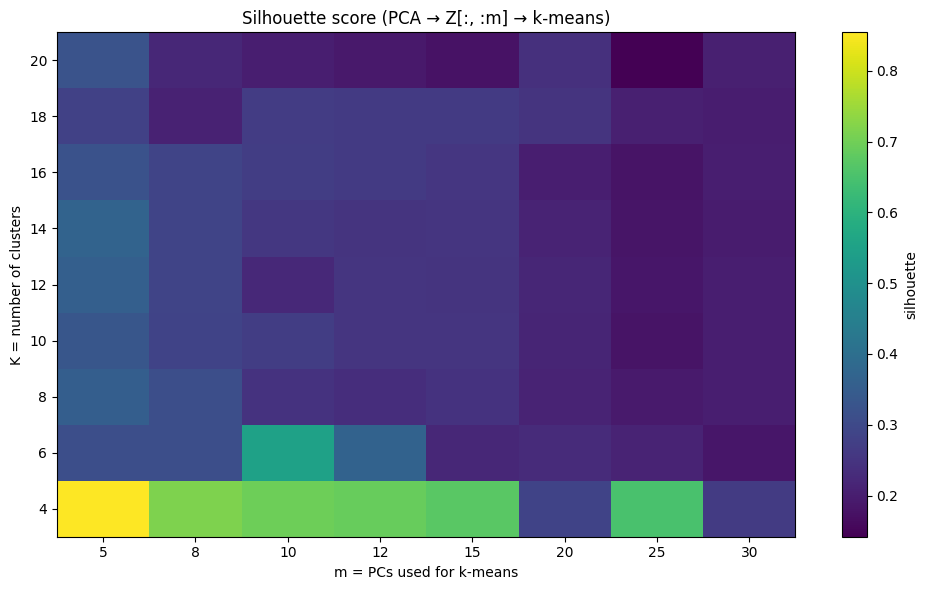

In [10]:
pivot_sil = grid_df.pivot(index="K", columns="m", values="silhouette")
fig, ax = plt.subplots(figsize=(10, 6))
im = ax.imshow(pivot_sil.values, aspect="auto", origin="lower", cmap="viridis")
ax.set_xticks(np.arange(len(pivot_sil.columns)))
ax.set_xticklabels(pivot_sil.columns)
ax.set_yticks(np.arange(len(pivot_sil.index)))
ax.set_yticklabels(pivot_sil.index)
ax.set_xlabel("m = PCs used for k-means")
ax.set_ylabel("K = number of clusters")
ax.set_title("Silhouette score (PCA → Z[:, :m] → k-means)")
cbar = plt.colorbar(im, ax=ax)
cbar.set_label("silhouette")
plt.tight_layout()


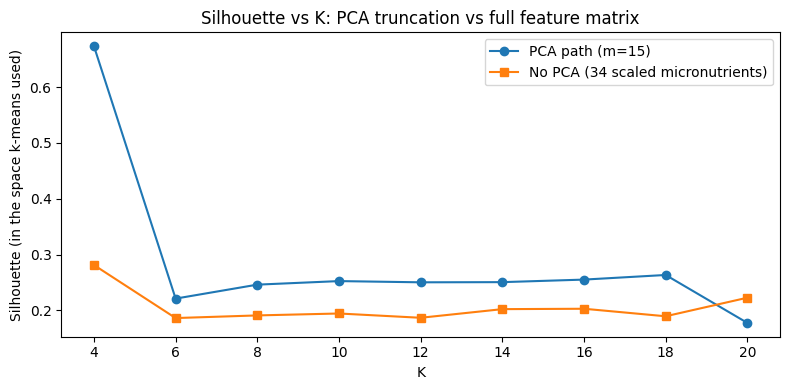

In [11]:
m_line = 15 if 15 in m_grid else m_grid[len(m_grid) // 2]
sub_pca = grid_df[grid_df["m"] == m_line].sort_values("K")
fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(sub_pca["K"], sub_pca["silhouette"], marker="o", label=f"PCA path (m={m_line})")
sub_raw = no_pca_df.sort_values("K")
ax.plot(
    sub_raw["K"],
    sub_raw["silhouette"],
    marker="s",
    label=f"No PCA ({p} scaled micronutrients)",
)
ax.set_xlabel("K")
ax.set_ylabel("Silhouette (in the space k-means used)")
ax.set_title("Silhouette vs K: PCA truncation vs full feature matrix")
ax.legend()
plt.tight_layout()


### Stability across random seeds

k-means includes random initialization. Below: **adjusted Rand index (ARI)** between cluster labels for seeds 42, 17, and 99 (1 = identical partitions up to label permutations). We evaluate the **best \((K,m)\)** from the grid by silhouette and the **baseline** \((K, m) = (8, 15)\).


In [12]:
def kmeans_labels(Z_sub: np.ndarray, k: int, seed: int) -> np.ndarray:
    km = KMeans(n_clusters=k, random_state=seed, n_init="auto")
    return km.fit_predict(Z_sub)


best_row = grid_df.loc[grid_df["silhouette"].idxmax()]
pair_candidates = [
    (int(best_row["K"]), int(best_row["m"])),
    (int(K), int(PC_FOR_KMEANS)),
]
seen = set()
pairs_eval = []
for pair in pair_candidates:
    if pair not in seen:
        seen.add(pair)
        pairs_eval.append(pair)

seeds_stable = [42, 17, 99]
stab_rows = []
for k_s, m_s in pairs_eval:
    Zm = Z_full[:, :m_s]
    labs = [kmeans_labels(Zm, k_s, s) for s in seeds_stable]
    stab_rows.append(
        {
            "K": k_s,
            "m": m_s,
            "ARI_42_17": adjusted_rand_score(labs[0], labs[1]),
            "ARI_42_99": adjusted_rand_score(labs[0], labs[2]),
            "ARI_17_99": adjusted_rand_score(labs[1], labs[2]),
        }
    )
stab_df = pd.DataFrame(stab_rows)
display(stab_df)


,K,m,ARI_42_17,ARI_42_99,ARI_17_99
0,4,5,0.024919,0.026343,0.708796
1,8,15,0.748764,0.660434,0.769424


### Interpreting PCs: top nutrient loadings

Each row of `pca.components_` shows how standardized nutrients combine to form a PC (weights in **scaled** feature space). Below: nutrients with largest absolute loading on PC1–PC3.


In [13]:
def top_loadings(pca, feature_names, pc_idx, topn=8):
    loadings = pca.components_[pc_idx]
    order = np.argsort(np.abs(loadings))[::-1][:topn]
    return pd.DataFrame(
        {"nutrient": [feature_names[i] for i in order], "loading": loadings[order]}
    )


for j in range(3):
    print(f"\n--- PC{j + 1} (explained var ratio = {evr_grid[j] * 100:.2f}%) ---")
    display(top_loadings(pca_grid, feat_names, j))



--- PC1 (explained var ratio = 21.25%) ---


,nutrient,loading
0,Niacin,0.300989
1,"Folate, DFE",0.299015
2,Riboflavin,0.298380
3,"Folate, total",0.295268
4,Thiamin,0.276119
5,Folic acid,0.270725
6,Vitamin B-6,0.221454
7,"Magnesium, Mg",0.209703



--- PC2 (explained var ratio = 9.50%) ---


,nutrient,loading
0,"Vitamin A, RAE",0.348374
1,Retinol,0.337906
2,Vitamin B-12,0.323798
3,"Copper, Cu",0.302521
4,Thiamin,-0.295848
5,"Folate, DFE",-0.277744
6,Folic acid,-0.269998
7,"Folate, total",-0.264794



--- PC3 (explained var ratio = 8.23%) ---


,nutrient,loading
0,"Carotene, beta",0.480472
1,Lutein + zeaxanthin,0.455349
2,Vitamin K (phylloquinone),0.455027
3,"Carotene, alpha",0.251436
4,"Vitamin A, RAE",0.233777
5,"Vitamin C, total ascorbic acid",0.216364
6,"Phosphorus, P",-0.189629
7,"Folate, food",0.171882


In [14]:
grid_csv = RESULTS_DIR / "unsupervised_grid_k_m_metrics.csv"
no_pca_csv = RESULTS_DIR / "unsupervised_grid_k_no_pca_metrics.csv"
grid_df.to_csv(grid_csv, index=False)
no_pca_df.to_csv(no_pca_csv, index=False)
print(f"Wrote {grid_csv.name} and {no_pca_csv.name} under {RESULTS_DIR}")


Wrote unsupervised_grid_k_m_metrics.csv and unsupervised_grid_k_no_pca_metrics.csv under /Users/conny/Desktop/BST 263/FinalProject/StatLearning_FinalProject/results
